In [12]:
import numpy as np
import numpy.polynomial.polynomial as poly
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mp

from google.colab import drive

In [13]:
# Mount Drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## Creating a snake density model

## Load and correct raw data

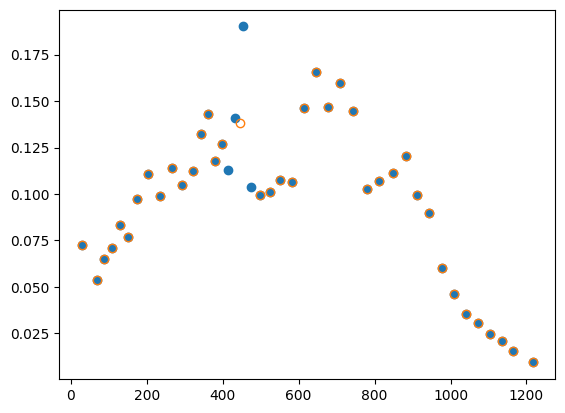

In [ ]:
#raw data from dissesction

svl = 961.1249667 #measurements are all in mm
totall = 1251.13491665
totalm = 115.77 #measured in grams

#measured in mm
segment_lengths = [57.4805,20.3758,21.1928,19.993,21.764,21.8136,24.3216,33.6696,30.25375,29.022,28.18725,
                   25.331,20.91725,15.82075,18.61375,16.798,15.87583333,20.07883333,21.72183333,22.02016667,
                   24.43533333,27.96383333,27.867,33.50075,32.2285,30.17275,31.6975,31.28025,38.43975,33.26575,
                   33.3676,35.7338,32.314,30.14383333,33.463,31.5284,32.7924,32.7105,30.3954,32.0032,27.5916,
                   33.2892,69.69925]

#measured in grams
segment_masses = [4.17,1.09,1.38,1.42,1.81,1.68,2.36,3.72,3,3.31,2.95,2.85,2.77,2.26,2.19,2.13,1.79,2.83,
                    4.13,2.28,2.43,2.82,3,3.57,4.71,5,4.66,5,5.57,3.41,3.57,3.98,3.9,3,3.01,1.9,1.51,
                  1.15,0.93,0.79,0.57,0.52,0.65]

#list of position in mm along snake at midpoint of each segment
segment_midpts = [segment_lengths[0]/2]

for i in np.arange(1,len(segment_lengths)):
    thing = segment_midpts[-1]+(segment_lengths[i]+segment_lengths[i-1])/2
    segment_midpts.append(thing)

#list of segment densities
segment_densities = [i/j for j,i in zip(segment_lengths,segment_masses)] #denisties in g/mm

plt.plot(segment_midpts,segment_densities,'o')

#editing segment masses for section between points 16 and 19, because snake was crushed there
#and mass was redistributed

section_mass = sum(segment_masses[16:20])
section_length = sum(segment_lengths[16:20])

del segment_masses[17:20]
del segment_lengths[17:20]

segment_masses[16] = section_mass
segment_lengths[16] = section_length

#new list of position in cm along snake at midpoint of each segment
new_segment_midpts = [segment_lengths[0]/2]

for i in np.arange(1,len(segment_lengths)):
    thing = new_segment_midpts[-1]+ (segment_lengths[i]+segment_lengths[i-1])/2
    new_segment_midpts.append(thing)

new_segment_densities = [i/j for i,j in zip(segment_masses,segment_lengths)]


plt.plot(new_segment_midpts,new_segment_densities,'o',mfc='none')

## Fit a curve for density in g/cm

Text(0.5, 0, 'Length along the snake')

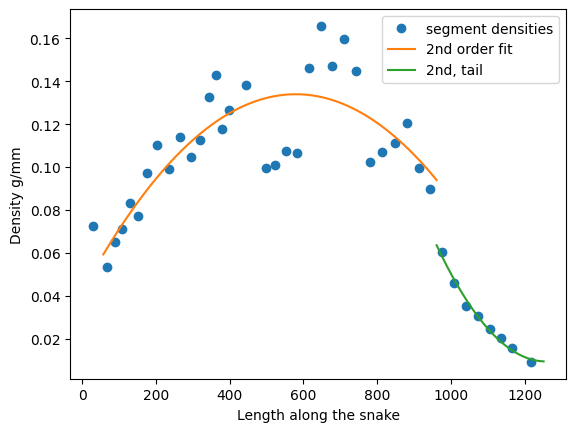

In [ ]:
#fit a parabola to the normalized data to body segments
#tail starts at segment 32.
#also removing head because higher density.

x = new_segment_midpts[1:32]
y = new_segment_densities[1:32]

coefs = poly.polyfit(x,y,2)


#SVL fit
xstart = segment_lengths[0] #start behind the head
fracSVL = 903.6444667 #903.6444667 is SVL without head length
numpts = int(np.round(fracSVL/0.1)) #each point should be 0.1 mm
x_new = np.linspace(xstart,svl,numpts)
ffit = poly.polyval(x_new, coefs)

plt.plot(new_segment_midpts,new_segment_densities,'o',label='segment densities')
plt.plot(x_new,ffit,label='2nd order fit')

#Tail fit
x1 = new_segment_midpts[32:]
y1 = new_segment_densities[32:]
coefs = poly.polyfit(x1,y1,2)
coefs1 = poly.polyfit(x1,y1,3)

tailpts = int(np.round((totall-svl)/0.1)) #length of the tail, 0.1mm spacing between points
x_new1 = np.linspace(svl,totall,tailpts)
ffit_t = poly.polyval(x_new1, coefs)

plt.plot(x_new1,ffit_t,label='2nd, tail')


plt.legend()
plt.ylabel('Density g/mm')
plt.xlabel('Length along the snake')

551.0553660837395
0.5733441385627253


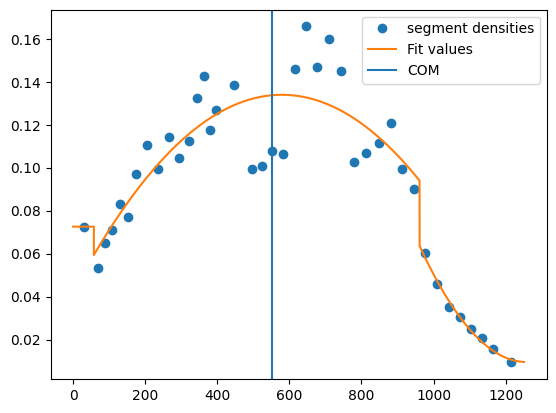

In [19]:
#concatenate head section, body section, and tail section into a single set of points.

head_section_density = new_segment_densities[0]
head_section_length = segment_lengths[0]
headpts = int(np.round(head_section_length/0.1)) #0.1mm per point

head_section_pts = np.linspace(0,head_section_length,headpts)
head_section_dens = np.full(np.shape(head_section_pts),head_section_density)

position_vals = np.concatenate((head_section_pts,x_new,x_new1))
density_vals = np.concatenate((head_section_dens,ffit,ffit_t))

plt.figure()
plt.plot(new_segment_midpts,new_segment_densities,'o',label='segment densities')
plt.plot(position_vals,density_vals,label='Fit values')

#use concatenated pieces to determine the COM
#xcm = sigma(mi*xi)/Mtotal where x=0 corresponds to nosetip.

#0.1mm per segment * xg/mm --> mass of segment
#create masses list:
masses = [0.1*i for i in density_vals]
mixi = [i*j for i,j in zip(masses, position_vals)]

xcm = np.sum(mixi)/np.sum(masses)
print(xcm)

#now in terms of %SVL
DP_PitchLim = xcm/svl
print(DP_PitchLim)

plt.axvline(xcm,label="COM")
plt.legend()

In [20]:
#doublecheck: what are torques on either side of this position?
rel_to_COM = [i-xcm for i in position_vals] #make all positions relative to COM, as opposed to relative to noestip
ximi = [i*j for i,j in zip(masses, rel_to_COM)] #torques for each segment
print(np.sum(ximi[:5510])) #sum all torques on left of COM
print(np.sum(ximi[5510:])) #sum all torques on right of COM
#should be same magnitued, opposite sign.

-13782.128726621584
13782.128726621582


# Chrysopelea

## Use density data to find COM

0.5320842051561528


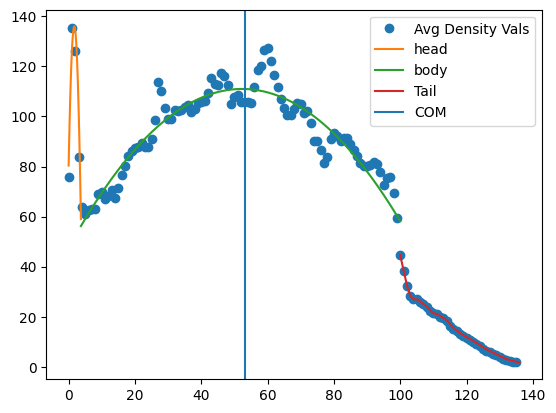

In [18]:
#define pitch point for CP based on density data

#1) Import Density Data
cp_dens = pd.read_csv('/content/drive/MyDrive/Astley equation paper/chrysopelea_snake_density.csv')
plt.plot(cp_dens['density (rho/rho_bar)']*100,'o',label="Avg Density Vals")

#2) Use parabolic fits from Yeaton dissertation for head, body:
#head is from 0 to 3.7% svl
headx = np.linspace(0,3.7,37) #10 points per % SVL
#body is from 3.7 to 100% SVL
bodyx = np.linspace(3.7,100,963)

#head fit
a = -1924.4/100
k = 1.36*100
h = 0.017*100
heady = a*np.square(headx-h)+k

#body fit
a = -2.32/100
k = 1.11*100
h = 0.523*100
bodyy = a*np.square(bodyx-h)+k

plt.plot(headx,heady,label='head')
plt.plot(bodyx,bodyy,label='body')

#tail only has one point per % SVL -- interpolate to get extra
x =  np.linspace(100,136,36)
y = 100*cp_dens['density (rho/rho_bar)'][100:]
tailx = np.linspace(100,136,360)
tail_interp = np.interp(tailx, x, y)

plt.plot(tailx,tail_interp,label="Tail")

#concatenate densities for head, body, and tail:
density_vals = np.concatenate((heady,bodyy,tail_interp))
position_vals = np.concatenate((headx,bodyx,tailx))



#use concatenated pieces to determine the COM
#xcm = sigma(mi*xi)/Mtotal where x=0 corresponds to nosetip.

masses = [i for i in density_vals]
mixi = [i*j for i,j in zip(masses, position_vals)] #this is in terms of % SVL

xcm = np.sum(mixi)/np.sum(masses)#this is in terms of % SVL
CP_com = xcm/100 #translate to fraction of SVL
print(CP_com)

plt.axvline(CP_com*100,label="COM")

plt.legend()

